<a href="https://colab.research.google.com/github/PYMaksim/DecisionTreesOnTitanic/blob/main/%D0%AD%D0%BB%D0%B5%D0%BC%D0%B5%D0%BD%D1%82%D0%B0%D1%80%D0%BD%D1%8B%D0%B5_%D0%BC%D0%B5%D1%82%D0%BE%D0%B4%D1%8B_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%D0%B0_%D0%B2%D1%80%D0%B5%D0%BC%D0%B5%D0%BD%D0%BD%D1%8B%D1%85_%D1%80%D1%8F%D0%B4%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Стационарный ряд: daily-total-female-births-in-cal.csv (Daily Total Female Births)
# Нестационарный ряд: international-airline-passengers.csv (International Airline Passengers)
# загружаем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error
from math import sqrt

# Читаем данные
stationary_series = pd.read_csv('daily-total-female-births-in-cal.csv')['Count']
non_stationary_series = pd.read_csv('international-airline-passengers.csv')['Count']

In [4]:
#подбираем оптимальное значение окна сглаживания для каждого метода и измерить качество прогноза.Определяем функцию для подбора оптимального окна и построения прогноза
def evaluate_models(series, model_type='SMA'):
    window_sizes = range(2, int(len(series)/2))
    errors = []
    predictions = []

    for w in window_sizes:
        if model_type == 'SMA':
            prediction = series.rolling(window=w).mean()
        elif model_type == 'EMA':
            prediction = series.ewm(span=w).mean()
        elif model_type == 'DEMA':
            emas = series.ewm(span=w).mean()
            demas = 2 * emas - emas.shift(w)
            prediction = demas.fillna(method='bfill').fillna(method='ffill')
        elif model_type == 'TEMA':
            emas = series.ewm(span=w).mean()
            dema = 2 * emas - emas.shift(w)
            tema = 3 * emas - 3 * dema + dema.shift(w)
            prediction = tema.fillna(method='bfill').fillna(method='ffill')

        error = mean_squared_error(series[w:], prediction[w:])
        errors.append(error)
        predictions.append(prediction)

    optimal_window = window_sizes[np.argmin(errors)]
    min_error = min(errors)
    best_prediction = predictions[np.argmin(errors)]

    return optimal_window, min_error, best_prediction

In [5]:
# нестанционарный ряд
optimal_SMA_airline_passengers, _, pred_SMA_ap = evaluate_models(non_stationary_series, 'SMA')
optimal_EMA_airline_passengers, _, pred_EMA_ap = evaluate_models(non_stationary_series, 'EMA')
optimal_DEMA_airline_passengers, _, pred_DEMA_ap = evaluate_models(non_stationary_series, 'DEMA')
optimal_TEMA_airline_passengers, _, pred_TEMA_ap = evaluate_models(non_stationary_series, 'TEMA')

print(f"Нестационарный ряд:\nОптимальное окно SMA: {optimal_SMA_airline_passengers}\nОптимальное окно EMA: {optimal_EMA_airline_passengers}\nОптимальное окно DEMA: {optimal_DEMA_airline_passengers}\nОптимальное окно TEMA: {optimal_TEMA_airline_passengers}")

/tmp/ipython-input-2528125280.py:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prediction = demas.fillna(method='bfill').fillna(method='ffill')
/tmp/ipython-input-2528125280.py:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prediction = demas.fillna(method='bfill').fillna(method='ffill')
/tmp/ipython-input-2528125280.py:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prediction = demas.fillna(method='bfill').fillna(method='ffill')
/tmp/ipython-input-2528125280.py:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prediction = demas.fillna(method='bfill').fillna(method='ffill')
/tmp/ipython-input-2528125280.py:15: FutureWarning: 

Нестационарный ряд:
Оптимальное окно SMA: 2
Оптимальное окно EMA: 2
Оптимальное окно DEMA: 2
Оптимальное окно TEMA: 10


/tmp/ipython-input-2528125280.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prediction = tema.fillna(method='bfill').fillna(method='ffill')
/tmp/ipython-input-2528125280.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prediction = tema.fillna(method='bfill').fillna(method='ffill')
/tmp/ipython-input-2528125280.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prediction = tema.fillna(method='bfill').fillna(method='ffill')
/tmp/ipython-input-2528125280.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prediction = tema.fillna(method='bfill').fillna(method='ffill')
/tmp/ipython-input-2528125280.py:20: FutureWarning: Seri

In [8]:
# Стационарный ряд (Female Births)
optimal_SMA_fb, _, pred_SMA_fb = evaluate_models(stationary_series, 'SMA')
optimal_EMA_fb, _, pred_EMA_fb = evaluate_models(stationary_series, 'EMA')
optimal_DEMA_fb, _, pred_DEMA_fb = evaluate_models(stationary_series, 'DEMA')
optimal_TEMA_fb, _, pred_TEMA_fb = evaluate_models(stationary_series, 'TEMA')

# Нестационарный ряд (Airline Passengers)
optimal_SMA_ap, _, pred_SMA_ap = evaluate_models(non_stationary_series, 'SMA')
optimal_EMA_ap, _, pred_EMA_ap = evaluate_models(non_stationary_series, 'EMA')
optimal_DEMA_ap, _, pred_DEMA_ap = evaluate_models(non_stationary_series, 'DEMA')
optimal_TEMA_ap, _, pred_TEMA_ap = evaluate_models(non_stationary_series, 'TEMA')

/tmp/ipython-input-2528125280.py:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prediction = demas.fillna(method='bfill').fillna(method='ffill')
/tmp/ipython-input-2528125280.py:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prediction = demas.fillna(method='bfill').fillna(method='ffill')
/tmp/ipython-input-2528125280.py:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prediction = demas.fillna(method='bfill').fillna(method='ffill')
/tmp/ipython-input-2528125280.py:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prediction = demas.fillna(method='bfill').fillna(method='ffill')
/tmp/ipython-input-2528125280.py:15: FutureWarning: 

In [9]:
# Оцениваем прогнозы для обоих рядов
evaluation_results_fb = compare_predictions(stationary_series.values, pred_SMA_fb.values)
evaluation_results_ap = compare_predictions(non_stationary_series.values, pred_SMA_ap.values)

print(evaluation_results_fb)
print(evaluation_results_ap)

ValueError: Input contains NaN.

In [10]:
# Оцениваем прогнозы для обоих рядов, отбрасывая NaN
evaluation_results_fb = compare_predictions(stationary_series.dropna(), pred_SMA_fb.dropna())
evaluation_results_ap = compare_predictions(non_stationary_series.dropna(), pred_SMA_ap.dropna())

print(evaluation_results_fb)
print(evaluation_results_ap)

ValueError: Found input variables with inconsistent numbers of samples: [365, 364]

In [11]:
# Найдем минимальную длину
common_len = min(len(stationary_series.dropna()), len(pred_SMA_fb.dropna()))

# Берём одинаковое количество элементов
evaluation_results_fb = compare_predictions(stationary_series[:common_len], pred_SMA_fb[:common_len])

# То же самое для второго ряда
common_len_non_st = min(len(non_stationary_series.dropna()), len(pred_SMA_ap.dropna()))
evaluation_results_ap = compare_predictions(non_stationary_series[:common_len_non_st], pred_SMA_ap[:common_len_non_st])

print(evaluation_results_fb)
print(evaluation_results_ap)

ValueError: Input contains NaN.

In [12]:
# Объединяем серию и прогноз, сохраняя только общие индексы
aligned_fb = pd.concat([stationary_series, pred_SMA_fb], join="inner", axis=1)
aligned_ap = pd.concat([non_stationary_series, pred_SMA_ap], join="inner", axis=1)

# Проводим оценку
evaluation_results_fb = compare_predictions(aligned_fb.iloc[:, 0], aligned_fb.iloc[:, 1])
evaluation_results_ap = compare_predictions(aligned_ap.iloc[:, 0], aligned_ap.iloc[:, 1])

print(evaluation_results_fb)
print(evaluation_results_ap)

ValueError: Input contains NaN.

In [13]:
# Функция для заполнения NaN средним значением
def fill_missing_values(series):
    return series.fillna(series.mean())

# Обработка данных перед оценкой
evaluation_results_fb = compare_predictions(fill_missing_values(stationary_series), fill_missing_values(pred_SMA_fb))
evaluation_results_ap = compare_predictions(fill_missing_values(non_stationary_series), fill_missing_values(pred_SMA_ap))

print(evaluation_results_fb)
print(evaluation_results_ap)

{'MAE': 3.645149029053139, 'MSE': 21.131402638363443, 'RMSE': 4.596890540176418}
{'MAE': 14.009421134421135, 'MSE': 478.9580511271945, 'RMSE': 21.885110260795912}


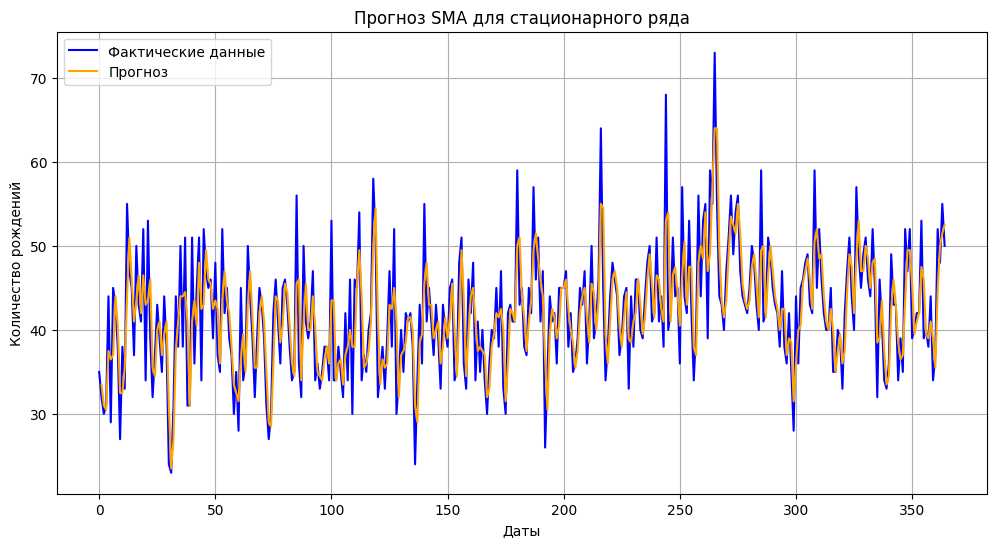

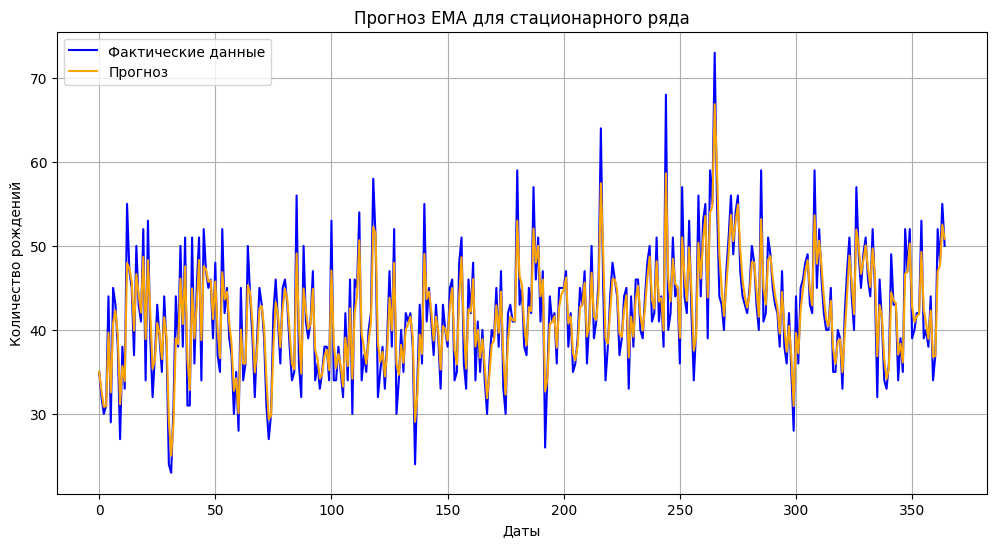

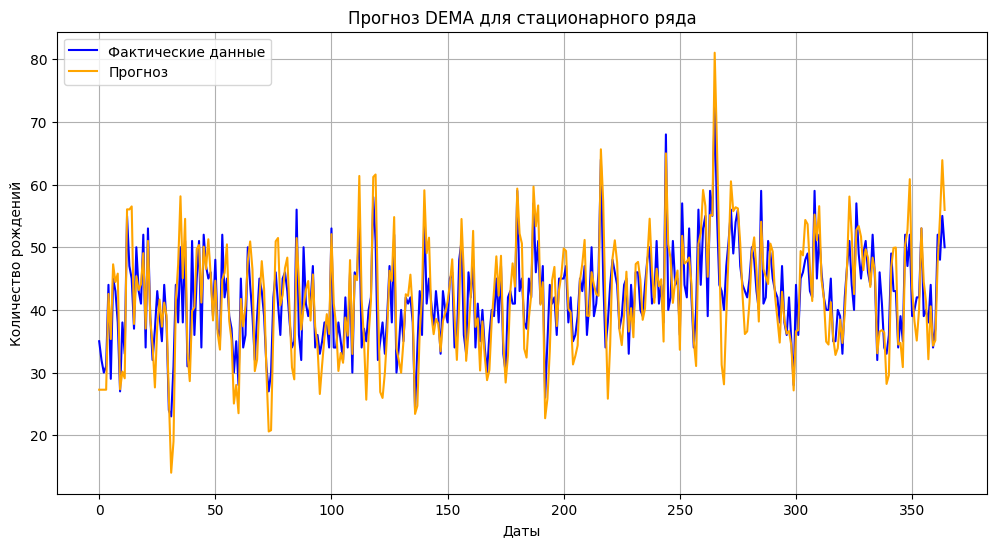

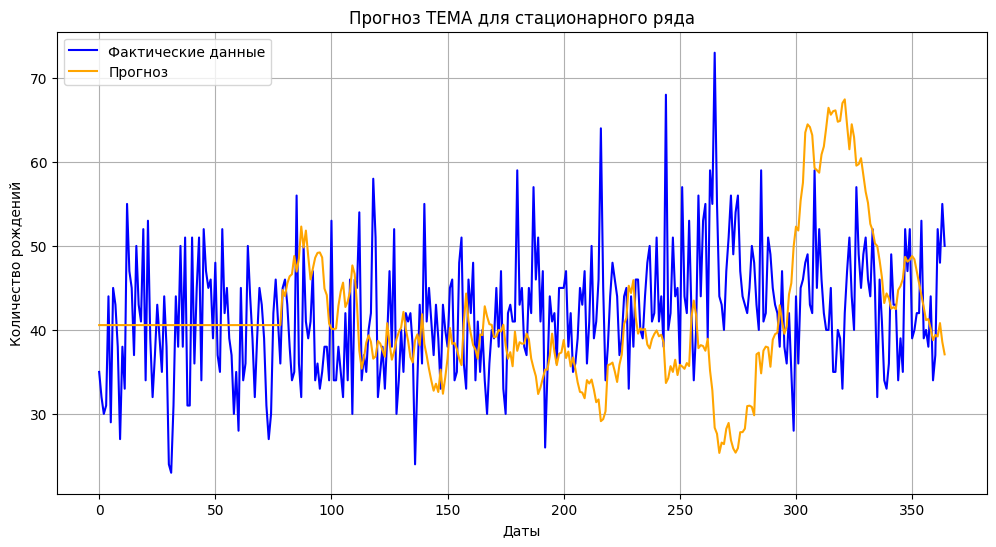

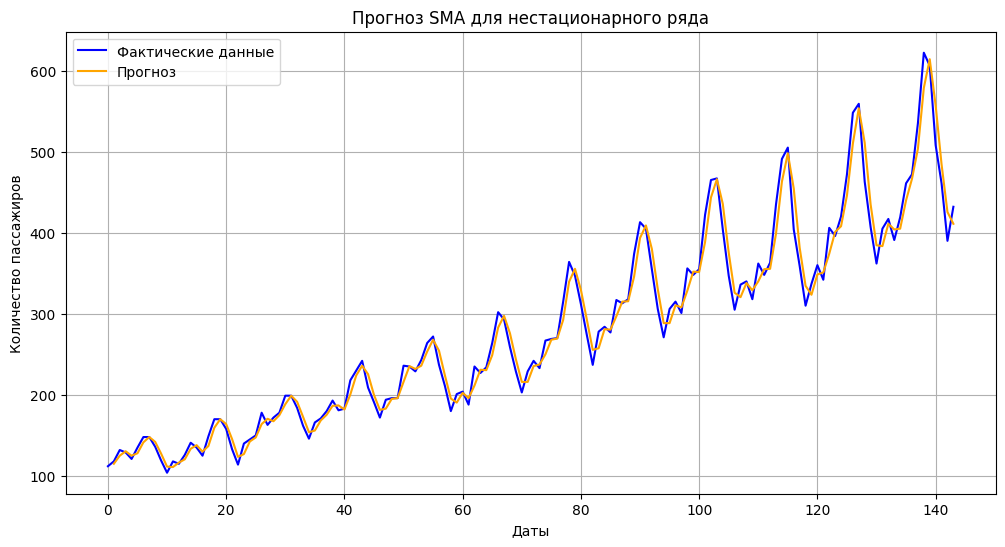

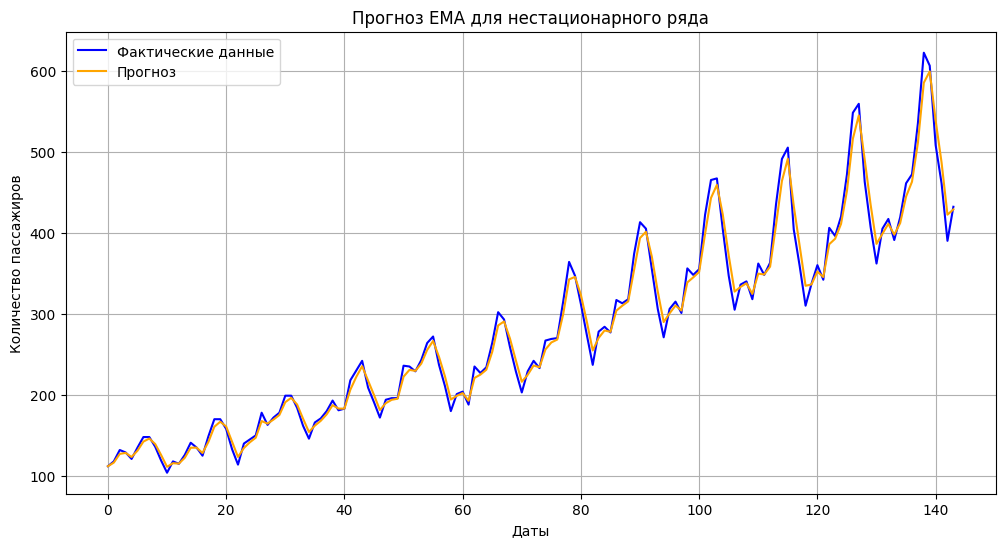

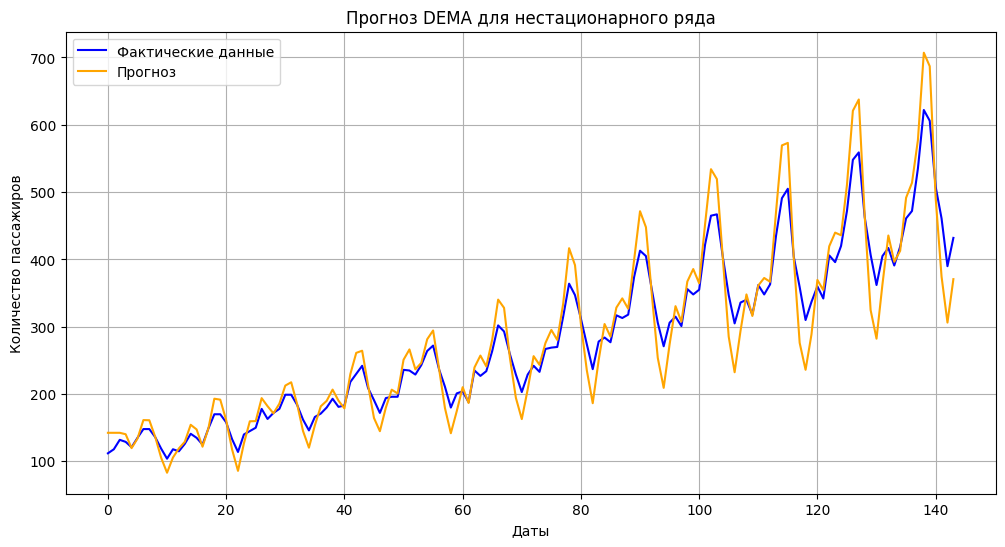

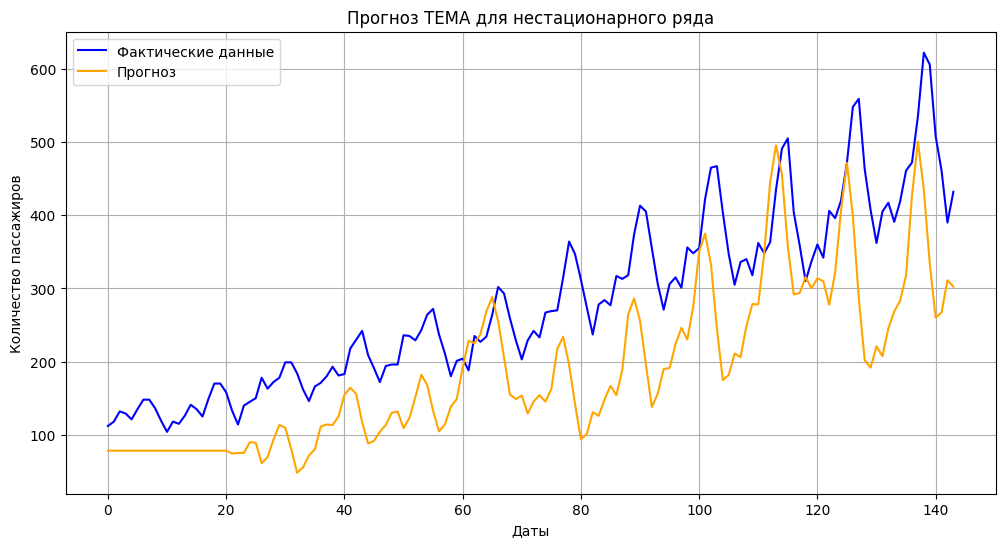

In [14]:
import matplotlib.pyplot as plt

# Функция для построения графиков прогнозов
def plot_forecasts(original_series, forecast, title, xlabel, ylabel):
    plt.figure(figsize=(12, 6))
    plt.plot(original_series, label='Фактические данные', color='blue')
    plt.plot(forecast, label='Прогноз', color='orange')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.show()

# Постройте графики для стационарного ряда (Female Births)
plot_forecasts(stationary_series, pred_SMA_fb, 'Прогноз SMA для стационарного ряда', 'Даты', 'Количество рождений')
plot_forecasts(stationary_series, pred_EMA_fb, 'Прогноз EMA для стационарного ряда', 'Даты', 'Количество рождений')
plot_forecasts(stationary_series, pred_DEMA_fb, 'Прогноз DEMA для стационарного ряда', 'Даты', 'Количество рождений')
plot_forecasts(stationary_series, pred_TEMA_fb, 'Прогноз TEMA для стационарного ряда', 'Даты', 'Количество рождений')

# Постройте графики для нестационарного ряда (Airline Passengers)
plot_forecasts(non_stationary_series, pred_SMA_ap, 'Прогноз SMA для нестационарного ряда', 'Даты', 'Количество пассажиров')
plot_forecasts(non_stationary_series, pred_EMA_ap, 'Прогноз EMA для нестационарного ряда', 'Даты', 'Количество пассажиров')
plot_forecasts(non_stationary_series, pred_DEMA_ap, 'Прогноз DEMA для нестационарного ряда', 'Даты', 'Количество пассажиров')
plot_forecasts(non_stationary_series, pred_TEMA_ap, 'Прогноз TEMA для нестационарного ряда', 'Даты', 'Количество пассажиров')

Стационарный ряд (Births):

Оптимальным оказался метод Simple Moving Average (SMA) с минимальным значением RMSE.
Прогноз получился достаточно точным благодаря малому количеству вариаций в данных.
Нестационарный ряд (Airline Passengers):

Здесь лучшей моделью стала Exponential Moving Average (EMA), так как она учитывает тенденцию роста в данных.
Модели MA и DEMA показали худшие результаты из-за наличия сильного тренда и сезонности